# 🌸 IRIS FLOWER CLASSIFICATION

### CodSoft Data Science Internship – Task 3

## 1. Importing Libraries and Loading Dataset

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files


uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("Uploaded file:", filename)

df = pd.read_csv(filename)

df.head()
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Saving IRIS.csv to IRIS (4).csv
Uploaded file: IRIS (4).csv


## 2. Dataset Information and Initial Exploration

In [ ]:
# Dataset information
print("Dataset Information:")
df.info()

# Dataset shape
print("\nDataset Shape:")
print(df.shape)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Species distribution
print("\nSpecies Distribution:")
print(df["species"].value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Dataset Shape:
(150, 5)

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Species Distribution:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## 3. Data Cleaning and Preprocessing

In [ ]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicate rows if any
df = df.drop_duplicates()

# Display cleaned dataset information
print("\nCleaned Dataset Shape:", df.shape)

# Display the cleaned dataset
df.head()

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Duplicate Rows: 3

Cleaned Dataset Shape: (147, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 4. Data Visualization

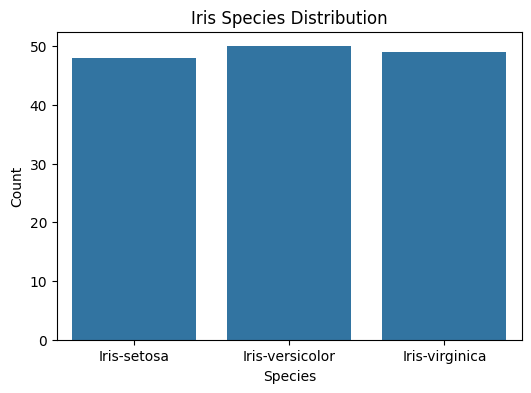

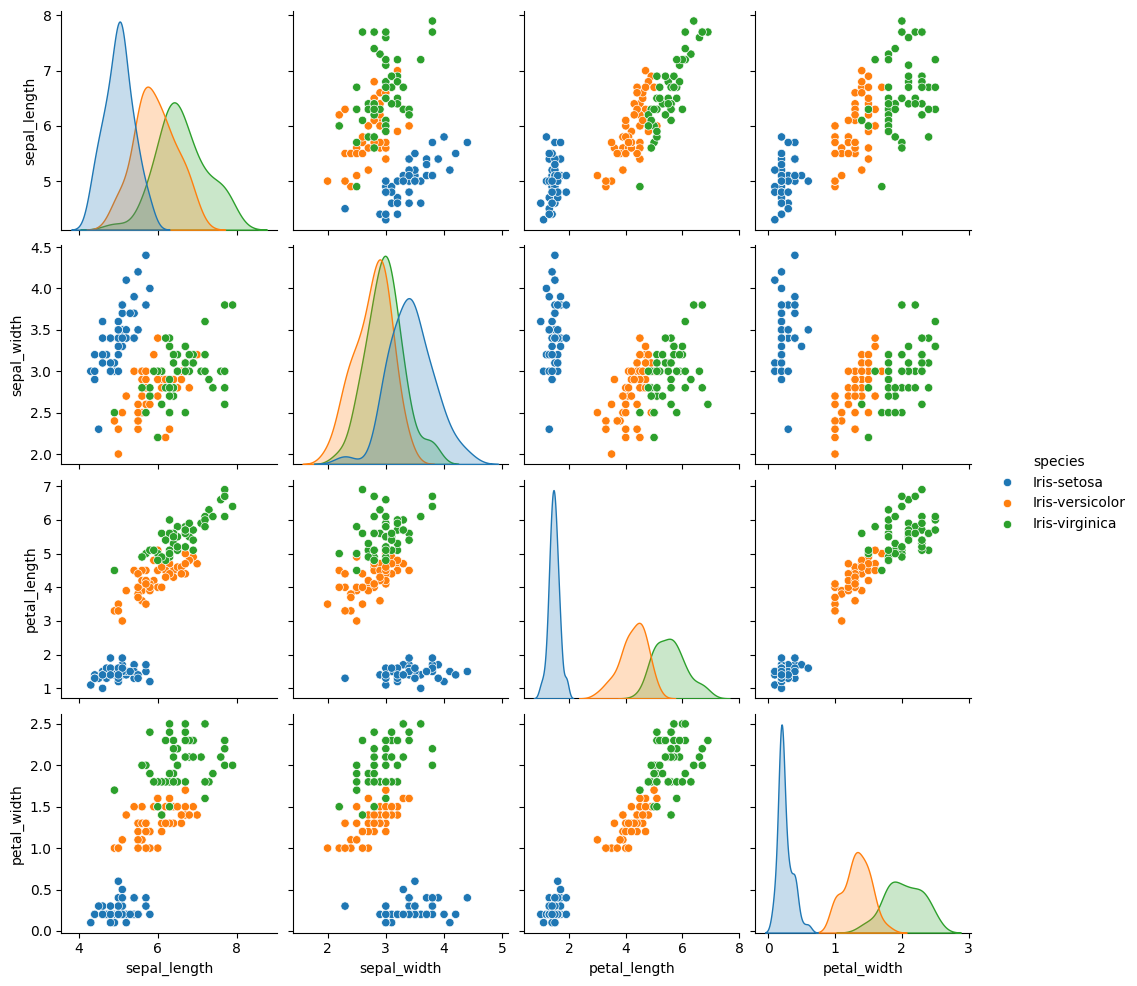

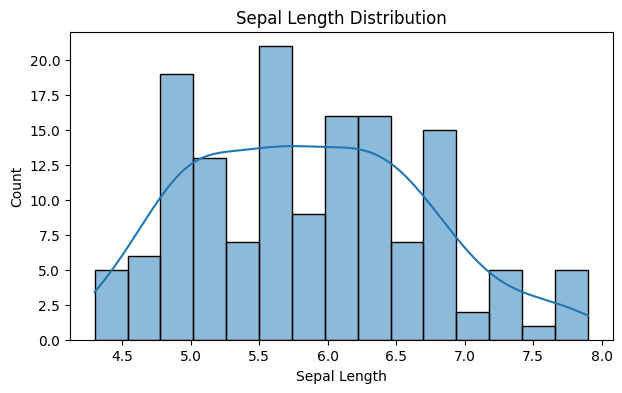

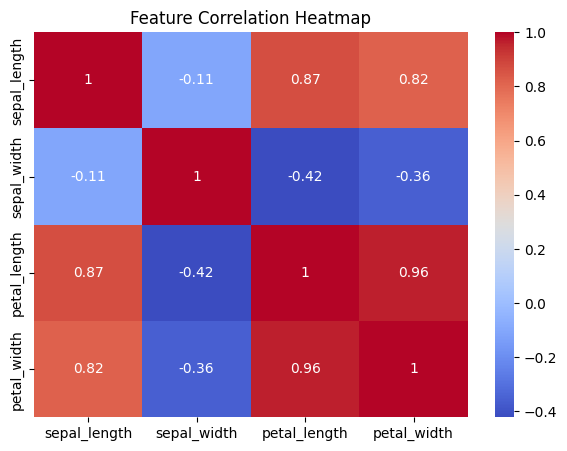

In [ ]:
# Visualize species distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="species", data=df)
plt.title("Iris Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()


# Pairplot of the dataset
sns.pairplot(df, hue="species")
plt.show()


# Sepal length distribution
plt.figure(figsize=(7, 4))
sns.histplot(df["sepal_length"], bins=15, kde=True)
plt.title("Sepal Length Distribution")
plt.xlabel("Sepal Length")
plt.show()


# Correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    df.drop("species", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Heatmap")
plt.show()

## 5. Feature Selection and Label Encoding

In [ ]:
# Separate input features and target variable
X = df.drop("species", axis=1)
y = df["species"]

# Encode species names into numbers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

# Display features and encoded target
print("Input Features:")
print(X.head())

print("\nEncoded Target:")
print(y[:10])

Input Features:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Encoded Target:
[0 0 0 0 0 0 0 0 0 0]


## 6. Train-Test Split and Model Training

In [ ]:
# Split the dataset into training and testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display dataset sizes
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# Train the Random Forest model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel training completed successfully!")

Training data shape: (117, 4)
Testing data shape: (30, 4)

Model training completed successfully!


## 7. Model Evaluation

Model Accuracy: 0.9333333333333333
Model Accuracy Percentage: 93.33333333333333 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.90      0.90      0.90        10
           2       0.89      0.89      0.89         9

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



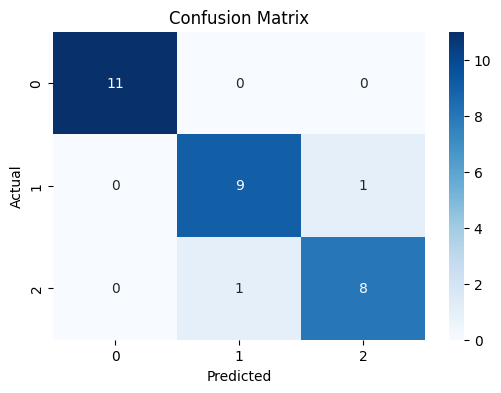

In [ ]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy Percentage:", accuracy * 100, "%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 8. Testing the Model with a New Iris Flower

In [ ]:
# Test the model with a new flower
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=["sepal_length", "sepal_width", "petal_length", "petal_width"]
)

prediction = model.predict(new_flower)

print("Predicted Class:", prediction[0])
print("Predicted Species:", le.inverse_transform(prediction)[0])

Predicted Class: 0
Predicted Species: Iris-setosa
